# 8. Sector Panel: Does Aggregation Hide the Response?

The index-level study concluded that ASPI response to qualifying disasters is not
predictable, and the explanation it offered for that was **aggregation**: a national index
blends twenty sectors, so a shock that lands hard on plantations and hotels is diluted by
nineteen other sectors that barely move.

That explanation is testable, and the data to test it has been sitting in the same
workbook all along. `07Market Indices - Daily.xls` carries **20 daily sector indices**
alongside the ASPI column the pipeline was reading. The same 64 events measured against 20
sectors gives roughly **1,200 real (event, sector) observations** — no simulation, no
synthetic rows, no relaxed inclusion criteria.

### Two disciplines this panel must respect

**Folds split on events, never inside one.** All 20 sector rows for an event live on the
same side of every boundary. Splitting by row would put some of an event's sectors in
training and the rest in test, and since sectors move together on the day of a shock, that
leaks the answer across the boundary.

**Effective N is not 1,280.** Sector returns are strongly cross-correlated within an
event, so the true information content lies somewhere between 64 and 1,280. Every interval
here comes from an **event-level block bootstrap** that resamples whole events with all
their sectors attached. Resampling rows independently would shrink intervals by roughly
√20 and manufacture significance out of the clustering.

Y2 has no sector analogue — the CSE reports volume market-wide, not per sector — so this
panel carries Y1 and Y3 only.

## 8.1 Environment and cached inputs

Loads `_shared.py` (paths, the artifact cache helpers, the target definitions) and applies the thesis figure style, then prints the artifact cache so it is visible which upstream stage produced these inputs and when. Reads `dataset` plus the sector index sheet from `data/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403

import numpy as np
from src.evaluation import figures as fx
from src.data_pipeline.cse_raw_loaders import load_sector_indices
from src.data_pipeline.sector_panel import (build_sector_panel, event_block_bootstrap,
                                            grouped_walk_forward)

fx.apply_thesis_style()

sector_long = load_sector_indices(DATA_DIR / "07Market Indices - Daily.xls")
in_scope = load_frame("in_scope")
dataset = load_frame("dataset")
spec = load_json("feature_spec")

cov = sector_long.groupby("sector")["date"].agg(["count", "min", "max"])
print(f"{sector_long['sector'].nunique()} sector indices, {len(sector_long):,} daily rows")
print(cov.to_string())


20 sector indices, 108,982 daily rows
                             count        min        max
sector                                                  
Banks Finance & Insurance     5597 2000-01-03 2023-06-28
Beverage, Food & Tobacco      5597 2000-01-03 2023-06-28
Chemicals & Pharmaceuticals   5597 2000-01-03 2023-06-28
Construction & Engineering    5597 2000-01-03 2023-06-28
Diversified                   5597 2000-01-03 2023-06-28
Footwear & Textile            5597 2000-01-03 2023-06-28
Healthcare                    5069 2002-03-15 2023-06-28
Hotels & Travels              5597 2000-01-03 2023-06-28
IT                            5029 2002-05-20 2023-06-28
Investment Trusts             5597 2000-01-03 2023-06-28
Land & Property               5597 2000-01-03 2023-06-28
Manufacturing                 5597 2000-01-03 2023-06-28
Motors                        5596 2000-01-03 2023-06-28
Oil Palms                     5597 2000-01-03 2023-06-28
Plantations                   4950 2000-01-03 2020

## 8.2 Build the panel

Each sector's close series is run through the same `FeatureEngineer` that produced the
index-level table, presented with the sector index as its price column. Targets and
features therefore come from exactly the same code path — there is no parallel
implementation to drift out of sync with the main study.

In [2]:
# Disaster covariates travel with each event and are identical across its sectors.
DISASTER_COLS = [c for c in ("log_financial_damage", "log_population_affected",
                             "damage_to_gdp", "days_since_last_disaster",
                             "disasters_trailing_365d")
                 if c in dataset.columns]
# Numeric one-hots only. `disaster_type` also starts with "disaster_" but holds the
# type NAME as a string, and sweeping it in here made the design matrix non-numeric.
DISASTER_COLS += [c for c in dataset.columns
                  if c.startswith("disaster_") and c != "disaster_type"
                  and pd.api.types.is_numeric_dtype(dataset[c])]

events = dataset[["event_date"] + DISASTER_COLS].copy()
panel = build_sector_panel(sector_long, events)

# Sector fixed effects: a sector's own average response is part of what we are testing.
panel = pd.concat([panel, pd.get_dummies(panel["sector"], prefix="sec", dtype=float)], axis=1)

print(f"panel: {len(panel):,} rows = {panel['event_id'].nunique()} events "
      f"x {panel['sector'].nunique()} sectors")
print(f"Y1 non-null: {panel['Y1_sector_log_return'].notna().sum():,}   "
      f"Y3 non-null: {panel['Y3_sector_recovery_days'].notna().sum():,}")
save_frame(panel.drop(columns=["asof_date", "date"], errors="ignore"), "sector_panel",
           "One row per (event, sector), Y1 and Y3 only.")


panel: 1,291 rows = 66 events x 20 sectors
Y1 non-null: 1,291   Y3 non-null: 1,291


cached sector_panel.parquet  (1291 rows x 59 cols)


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/sector_panel.parquet')

## 8.3 How much do sectors differ on event days?

Before fitting anything: if every sector moved identically on event days, the panel would
carry no more information than the index and the whole exercise would be pointless. The
dispersion below is what the extension is betting on.

In [3]:
by_sector = (panel.groupby("sector")["Y1_sector_log_return"]
             .agg(mean="mean", sd="std", worst="min", n="count")
             .sort_values("mean"))
print("Event-day log return by sector, across all events:")
print(by_sector.to_string())

within = panel.groupby("event_id")["Y1_sector_log_return"].std()
print(f"\nMedian cross-sector dispersion WITHIN an event: {within.median():.5f}")
print(f"Index-level Y1 standard deviation ACROSS events:  "
      f"{dataset['Y1_aspi_log_return'].std():.5f}")
print("\nIf within-event dispersion is comparable to across-event variation, sectors are")
print("responding differently and the index is averaging that signal away.")


Event-day log return by sector, across all events:
                                 mean        sd     worst   n
sector                                                       
Trading                     -0.005065  0.014807 -0.060847  66
Investment Trusts           -0.004072  0.016812 -0.096346  66
Motors                      -0.003752  0.022264 -0.106673  66
Hotels & Travels            -0.003450  0.019057 -0.097179  66
Power & Energy              -0.003216  0.021532 -0.079031  62
Plantations                 -0.002827  0.017939 -0.097671  54
Manufacturing               -0.002540  0.016119 -0.074424  66
IT                          -0.002473  0.026083 -0.085071  62
Beverage, Food & Tobacco    -0.002238  0.013604 -0.072920  66
Oil Palms                   -0.001573  0.018503 -0.063330  66
Diversified                 -0.000766  0.021062 -0.086255  66
Footwear & Textile          -0.000590  0.017774 -0.083883  66
Construction & Engineering  -0.000276  0.026731 -0.068232  66
Land & Property    

## 8.4 Walk-forward on the panel

Same geometry as the index-level study — 30 training events, 10 test events, step 10 —
but the unit is now the event group, so each fold trains on roughly 600 rows instead of
30. Ridge and Random Forest only: the point is whether the *data* carries signal, not
which model family wins.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MARKET_COLS = [c for c in ("lag_return_t-1", "lag_return_t-2", "lag_return_t-3",
                           "lag_return_t-5", "price_to_sma_5", "price_to_ema_5",
                           "price_to_sma_10", "price_to_ema_10", "price_to_sma_20",
                           "price_to_ema_20", "rolling_std_5", "rolling_std_10",
                           "rolling_std_20", "rolling_std_30", "squared_return")
               if c in panel.columns]
SEC_COLS = [c for c in panel.columns if c.startswith("sec_")]
PANEL_FEATURES = MARKET_COLS + DISASTER_COLS + SEC_COLS
PANEL_TARGETS = ["Y1_sector_log_return", "Y3_sector_recovery_days"]

Xp = panel[PANEL_FEATURES].astype(float).fillna(0.0)
yp = panel[PANEL_TARGETS]
folds = list(grouped_walk_forward(panel, train_events=30, test_events=10, step=10))
print(f"{len(folds)} grouped folds, {len(PANEL_FEATURES)} features")
for i, (tr, te) in enumerate(folds):
    assert not (set(panel["event_id"].iloc[tr]) & set(panel["event_id"].iloc[te])), \
        "event split across a fold boundary -- would leak"
    print(f"  fold {i}: train {len(tr):4d} rows / {panel['event_id'].iloc[tr].nunique()} events"
          f"   test {len(te):4d} rows / {panel['event_id'].iloc[te].nunique()} events")
print("all folds verified: no event appears on both sides of a boundary")


3 grouped folds, 44 features
  fold 0: train  583 rows / 30 events   test  200 rows / 10 events
  fold 1: train  600 rows / 30 events   test  200 rows / 10 events
  fold 2: train  600 rows / 30 events   test  194 rows / 10 events
all folds verified: no event appears on both sides of a boundary


### 8.4.1 Fit every model on every event-grouped fold

Folds are cut **between** events, never inside one. An ordinary row-level split would
put the same event's Plantations row in training and its Hotels row in test, which is
leakage even though no single row appears twice.

In [5]:
RIDGE_ALPHAS = np.logspace(-3, 3, 13)
panel_results = {m: {t: {"y_true": [], "y_pred": [], "event_id": [], "sector": []}
                     for t in PANEL_TARGETS}
                 for m in ("ridge", "random_forest", "naive_zero", "naive_train_mean")}

for tr, te in folds:
    for t in PANEL_TARGETS:
        ok_tr = tr[yp[t].iloc[tr].notna().to_numpy()]
        ok_te = te[yp[t].iloc[te].notna().to_numpy()]
        if len(ok_tr) < 20 or len(ok_te) == 0:
            continue
        X_tr, X_te = Xp.iloc[ok_tr], Xp.iloc[ok_te]
        y_tr, y_te = yp[t].iloc[ok_tr].to_numpy(), yp[t].iloc[ok_te].to_numpy()
        ev_te = panel["event_id"].iloc[ok_te].to_numpy()
        sec_te = panel["sector"].iloc[ok_te].to_numpy()

        lo, hi = (0.0, 90.0) if t.startswith("Y3") else (None, None)

        ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
        ridge.fit(X_tr, y_tr)
        rf = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_tr, y_tr)

        preds = {"ridge": ridge.predict(X_te), "random_forest": rf.predict(X_te),
                 "naive_zero": np.zeros(len(y_te)),
                 "naive_train_mean": np.full(len(y_te), float(np.mean(y_tr)))}
        for name, p in preds.items():
            panel_results[name][t]["y_true"].append(y_te)
            panel_results[name][t]["y_pred"].append(np.clip(p, lo, hi))
            panel_results[name][t]["event_id"].append(ev_te)
            panel_results[name][t]["sector"].append(sec_te)

print("panel walk-forward complete")


panel walk-forward complete


## 8.5 Results, with event-clustered intervals

The comparison that matters is against the same two nulls used at index level. A model
counts as beating a null only if the **event-block** bootstrap interval on ΔRMSE excludes
zero.

In [6]:
rows = []
for t in PANEL_TARGETS:
    yt = np.concatenate(panel_results["naive_zero"][t]["y_true"])
    ev = np.concatenate(panel_results["naive_zero"][t]["event_id"])
    for m in ("ridge", "random_forest", "naive_zero", "naive_train_mean"):
        p = np.concatenate(panel_results[m][t]["y_pred"])
        rows.append({"target": t, "model": m, "n_rows": len(yt),
                     "n_events": len(np.unique(ev)),
                     "rmse": float(np.sqrt(np.mean((p - yt) ** 2))),
                     "mae": float(np.mean(np.abs(p - yt))),
                     "r2_pooled": float(1 - np.sum((p - yt) ** 2) / np.sum((yt - yt.mean()) ** 2))})
panel_summary = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print(panel_summary.to_string(index=False))
save_frame(panel_summary, "sector_panel_summary", "Sector-panel walk-forward results.")


                 target            model  n_rows  n_events      rmse       mae  r2_pooled
   Y1_sector_log_return            ridge     594        30  0.029180  0.015185  -1.735914
   Y1_sector_log_return    random_forest     594        30  0.021568  0.012614  -0.494722
   Y1_sector_log_return       naive_zero     594        30  0.018141  0.010332  -0.057476
   Y1_sector_log_return naive_train_mean     594        30  0.019024  0.011467  -0.162918
Y3_sector_recovery_days            ridge     594        30 29.027023 22.176039  -0.193418
Y3_sector_recovery_days    random_forest     594        30 30.518188 23.055975  -0.319183
Y3_sector_recovery_days       naive_zero     594        30 28.739191 10.951178  -0.169867
Y3_sector_recovery_days naive_train_mean     594        30 26.778337 19.113937  -0.015675


cached sector_panel_summary.parquet  (8 rows x 7 cols)


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/sector_panel_summary.parquet')

### 8.5.1 Verdict per model and target

Intervals come from the event-block bootstrap, which resamples events and carries all
of an event's sectors together. A row-level bootstrap would treat 20 sectors moving
together on one shock day as 20 independent observations and report intervals several
times too narrow.

In [7]:
def _call(r):
    """Three outcomes, not two. An interval lying entirely below zero is a decisive
    negative, and reporting it as 'not distinguishable' would understate it."""
    if r["significant"]:
        return "BEATS"
    if r["ci_high"] < 0:
        return "SIGNIFICANTLY WORSE"
    return "not distinguishable"


print("SECTOR PANEL VERDICT (event-clustered bootstrap)\n" + "=" * 72)
verdict_rows = []
for t in PANEL_TARGETS:
    yt = np.concatenate(panel_results["naive_zero"][t]["y_true"])
    ev = np.concatenate(panel_results["naive_zero"][t]["event_id"])
    for m in ("ridge", "random_forest"):
        pm = np.concatenate(panel_results[m][t]["y_pred"])
        for base in ("naive_zero", "naive_train_mean"):
            pb = np.concatenate(panel_results[base][t]["y_pred"])
            r = event_block_bootstrap(ev, yt, pm, pb, n_boot=2000)
            verdict_rows.append({"target": t, "model": m, "baseline": base, **r})
            print(f"{t:<26s} {m:<14s} vs {base:<17s} "
                  f"dRMSE={r['delta_rmse']:+.5f}  95% CI [{r['ci_low']:+.5f}, {r['ci_high']:+.5f}]  "
                  f"{_call(r)}")
verdict = pd.DataFrame(verdict_rows)
save_frame(verdict, "sector_panel_verdict", "Event-clustered bootstrap verdicts.")
print(f"\nClustering matters: {verdict['n_rows'].iloc[0]} rows but only "
      f"{verdict['n_events'].iloc[0]} independent events.")


SECTOR PANEL VERDICT (event-clustered bootstrap)


Y1_sector_log_return       ridge          vs naive_zero        dRMSE=-0.01104  95% CI [-0.02061, -0.00180]  SIGNIFICANTLY WORSE


Y1_sector_log_return       ridge          vs naive_train_mean  dRMSE=-0.01016  95% CI [-0.01997, -0.00073]  SIGNIFICANTLY WORSE


Y1_sector_log_return       random_forest  vs naive_zero        dRMSE=-0.00343  95% CI [-0.00570, -0.00107]  SIGNIFICANTLY WORSE


Y1_sector_log_return       random_forest  vs naive_train_mean  dRMSE=-0.00254  95% CI [-0.00485, -0.00027]  SIGNIFICANTLY WORSE


Y3_sector_recovery_days    ridge          vs naive_zero        dRMSE=-0.28783  95% CI [-3.53850, +2.38253]  not distinguishable


Y3_sector_recovery_days    ridge          vs naive_train_mean  dRMSE=-2.24869  95% CI [-3.86011, -0.87190]  SIGNIFICANTLY WORSE


Y3_sector_recovery_days    random_forest  vs naive_zero        dRMSE=-1.77900  95% CI [-5.79141, +1.37575]  not distinguishable


Y3_sector_recovery_days    random_forest  vs naive_train_mean  dRMSE=-3.73985  95% CI [-6.76195, -1.53163]  SIGNIFICANTLY WORSE


cached sector_panel_verdict.parquet  (8 rows x 9 cols)

Clustering matters: 594 rows but only 30 independent events.


## 8.6 Sector-level classification

The index-level classification layer has **40 pooled test points**. This panel has
**~600 test rows drawn from 30 independent events** -- 15x the test set, all real, no
simulation. It is the largest genuine increase in evidence available to this study, and
until now the panel has only ever been used for regression.

Two things keep it honest, both already built and covered by
`tests/test_integrity_invariants.py`:

- `grouped_walk_forward` puts fold boundaries **between events**, never inside one. All 20
  sectors of an event live on the same side of every boundary; splitting them would leak
  the shock across the boundary and inflate every score here.
- Sectors co-move on a shock day, so the **effective N is between 30 and 600 and must never
  be reported as 600.** Every interval below therefore comes from `event_block_bootstrap`,
  which resamples whole events, not rows.

`C2_volume_spike` cannot run here: the CSE publishes volume market-wide, not per sector, so
the panel carries no Y2 and that label is all-NaN. It is skipped automatically rather than
being fed a fabricated value.

In [8]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from src.models.classifiers import (LABELS, build_classifiers, classification_metrics,
                                    summarise)

# The label functions index the canonical target names, so the panel's renamed columns are
# mapped back rather than duplicating five label definitions for the sector case.
PANEL_Y = panel.rename(columns={"Y1_sector_log_return": "Y1_aspi_log_return",
                                "Y3_sector_recovery_days": "Y3_recovery_days",
                                "Y1_sector_car_5": "Y1_car_5",
                                "Y1_sector_car_10": "Y1_car_10"})
for _needed in ("Y1_aspi_log_return", "Y2_abnormal_volume", "Y3_recovery_days",
                "Y1_car_5", "Y1_car_10"):
    if _needed not in PANEL_Y.columns:
        PANEL_Y[_needed] = np.nan          # Y2 has no sector analogue -- stays all-NaN
y_panel = PANEL_Y[["Y1_aspi_log_return", "Y2_abnormal_volume", "Y3_recovery_days",
                   "Y1_car_5", "Y1_car_10"]]


def _inner_cv(n_rows, n_splits=3):
    return TimeSeriesSplit(n_splits=max(2, min(n_splits, n_rows - 1)))


panel_clf = {name: {m: {"y_true": [], "y_score": [], "events": []}
                    for m in build_classifiers()} for name in LABELS}
skipped = []

for label_name, label_fn in LABELS.items():
    for fold_i, (tr, te) in enumerate(folds):
        labels = label_fn(y_panel, tr, panel)
        ok_tr = tr[labels.iloc[tr].notna().to_numpy()]
        ok_te = te[labels.iloc[te].notna().to_numpy()]
        if len(ok_tr) == 0 or len(ok_te) == 0:
            skipped.append((label_name, fold_i, "no non-missing rows"))
            continue
        l_tr = labels.iloc[ok_tr].to_numpy().astype(int)
        l_te = labels.iloc[ok_te].to_numpy().astype(int)
        if len(np.unique(l_tr)) < 2:
            skipped.append((label_name, fold_i, "one class in training window"))
            continue

        X_tr, X_te = Xp.iloc[ok_tr], Xp.iloc[ok_te]
        probe = RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, l_tr)
        feats = list(X_tr.columns[np.argsort(probe.feature_importances_)[::-1][:20]])

        for model_name, (estimator, grid) in build_classifiers().items():
            search = GridSearchCV(estimator, grid, cv=_inner_cv(len(X_tr)),
                                  scoring="roc_auc", n_jobs=-1, refit=True,
                                  error_score=np.nan)
            try:
                search.fit(X_tr[feats], l_tr)
                score = search.best_estimator_.predict_proba(X_te[feats])[:, 1]
            except Exception:
                try:
                    score = clone(estimator).fit(X_tr[feats], l_tr).predict_proba(X_te[feats])[:, 1]
                except Exception:
                    score = np.full(len(X_te), l_tr.mean())
            panel_clf[label_name][model_name]["y_true"].append(l_te)
            panel_clf[label_name][model_name]["y_score"].append(score)
            # Event ids travel with the predictions so the bootstrap can resample whole
            # events rather than rows.
            panel_clf[label_name][model_name]["events"].append(
                panel["event_id"].iloc[ok_te].to_numpy())

if skipped:
    print(f"skipped {len(skipped)} (label, fold) pairs:")
    for _l, _f, _why in skipped:
        print(f"  {_l} fold {_f}: {_why}")
    print()

records = []
for label_name, per_model in panel_clf.items():
    for model_name, arrays in per_model.items():
        if not arrays["y_true"]:
            continue
        yt = np.concatenate(arrays["y_true"])
        ys = np.concatenate(arrays["y_score"])
        ev = np.concatenate(arrays["events"])
        rec = classification_metrics(yt, ys)
        rec.update({"label": label_name, "model": model_name,
                    "n_events": int(len(np.unique(ev)))})
        records.append(rec)
        maj = classification_metrics(yt, np.full(len(yt), float(yt.mean() >= 0.5)))
        maj.update({"label": label_name, "model": "majority_baseline",
                    "n_events": int(len(np.unique(ev)))})
        records.append(maj)

panel_clf_summary = summarise(records).drop_duplicates(subset=["label", "model"])
cols = ["label", "model", "n", "n_pos", "prevalence", "majority_baseline_acc", "accuracy",
        "balanced_accuracy", "precision", "recall", "f1", "auc", "auc_boot_lo",
        "auc_boot_hi", "beats_baseline"]
print("SECTOR-PANEL CLASSIFICATION")
print(panel_clf_summary[[c for c in cols if c in panel_clf_summary.columns]]
      .round(3).to_string(index=False))
print()
_win = panel_clf_summary[panel_clf_summary["beats_baseline"]]
print(f">>> (label, model) pairs clearing BOTH the majority rule and chance: "
      f"{len(_win)} of {(panel_clf_summary['model'] != 'majority_baseline').sum()}")
if len(_win):
    print(_win[["label", "model", "balanced_accuracy", "auc", "auc_boot_lo", "auc_boot_hi"]]
          .round(3).to_string(index=False))
else:
    print("    none. Reported as measured.")
print()
print("Row counts are (event, sector) pairs. Effective N is the EVENT count, not the row "
      "count -- 20 sectors move together on a shock day.")

save_frame(panel_clf_summary, "sector_classification_summary",
           "Sector-panel classification, grouped folds, event-clustered.")

skipped 3 (label, fold) pairs:
  C2_volume_spike fold 0: no non-missing rows
  C2_volume_spike fold 1: no non-missing rows
  C2_volume_spike fold 2: no non-missing rows



SECTOR-PANEL CLASSIFICATION
             label             model   n  n_pos  prevalence  majority_baseline_acc  accuracy  balanced_accuracy  precision  recall    f1   auc  auc_boot_lo  auc_boot_hi  beats_baseline
C1_negative_return          logistic 594    224       0.377                  0.623     0.473              0.473      0.352   0.473 0.404 0.494        0.446        0.542           False
C1_negative_return majority_baseline 594    224       0.377                  0.623     0.623              0.500      0.000   0.000 0.000 0.500        0.500        0.500           False
C1_negative_return            rf_clf 594    224       0.377                  0.623     0.471              0.478      0.358   0.504 0.419 0.487        0.439        0.534           False
C1_negative_return           xgb_clf 594    224       0.377                  0.623     0.466              0.499      0.377   0.634 0.473 0.519        0.471        0.569           False
  C1b_adverse_move          logistic 594    121

>>> (label, model) pairs clearing BOTH the majority rule and chance: 0 of 15
    none. Reported as measured.

Row counts are (event, sector) pairs. Effective N is the EVENT count, not the row count -- 20 sectors move together on a shock day.


cached sector_classification_summary.parquet  (20 rows x 19 cols)


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/sector_classification_summary.parquet')

## 8.7 Which sectors respond, and is any of it predictable?

Per-sector out-of-fold error. Even where the pooled result is null, a sector-specific
pattern would be the most interesting finding available — and its absence is itself worth
reporting, because it closes off the aggregation explanation.

In [9]:
t = "Y1_sector_log_return"
yt = np.concatenate(panel_results["naive_zero"][t]["y_true"])
ev = np.concatenate(panel_results["naive_zero"][t]["event_id"])
pm = np.concatenate(panel_results["random_forest"][t]["y_pred"])
pz = np.concatenate(panel_results["naive_zero"][t]["y_pred"])

# Sector labels were recorded alongside the predictions during fitting. Reconstructing
# them from `folds` here would misalign whenever a fold was skipped as degenerate.
sec = np.concatenate(panel_results["random_forest"][t]["sector"])

per_sector = (pd.DataFrame({"sector": sec, "y": yt, "rf": pm, "zero": pz})
              .groupby("sector")
              .apply(lambda g: pd.Series({
                  "n": len(g),
                  "rmse_rf": float(np.sqrt(np.mean((g["rf"] - g["y"]) ** 2))),
                  "rmse_null": float(np.sqrt(np.mean((g["zero"] - g["y"]) ** 2))),
                  "mean_event_return": float(g["y"].mean())}), include_groups=False)
              .assign(skill=lambda d: 1 - d["rmse_rf"] / d["rmse_null"])
              .sort_values("skill", ascending=False))
print(per_sector.to_string())
print(f"\nsectors where RF beats the zero null on RMSE: "
      f"{int((per_sector['skill'] > 0).sum())}/{len(per_sector)}")
save_frame(per_sector.reset_index(), "sector_per_sector", "Out-of-fold error by sector.")


                                n   rmse_rf  rmse_null  mean_event_return     skill
sector                                                                             
Construction & Engineering   30.0  0.034882   0.032051           0.007427 -0.088331
Motors                       30.0  0.012982   0.011810           0.000353 -0.099315
IT                           30.0  0.025490   0.022732           0.000060 -0.121293
Telecommunications           30.0  0.029625   0.026111           0.009998 -0.134587
Banks Finance & Insurance    30.0  0.033370   0.029092           0.005302 -0.147043
Trading                      30.0  0.014927   0.012861          -0.002571 -0.160669
Diversified                  30.0  0.023311   0.020048           0.008306 -0.162736
Land & Property              30.0  0.019460   0.016378           0.006367 -0.188208
Stores & Supplies            30.0  0.027371   0.022911           0.005171 -0.194660
Investment Trusts            30.0  0.012360   0.010036           0.001472 -0

cached sector_per_sector.parquet  (20 rows x 6 cols)


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/sector_per_sector.parquet')

### 8.7.1 Sector response figure

Mean event-day return per sector beside the skill of the best model on each. The two
panels answer different questions: whether sectors respond differently at all, and
whether any of that difference is predictable in advance.

saved -> docs\figures\fig_31_sector_response_and_skill.png (221 KB)


cached results_sector.pkl


WindowsPath('F:/CSE-disaster-impact-predictor/artifacts/results_sector.pkl')

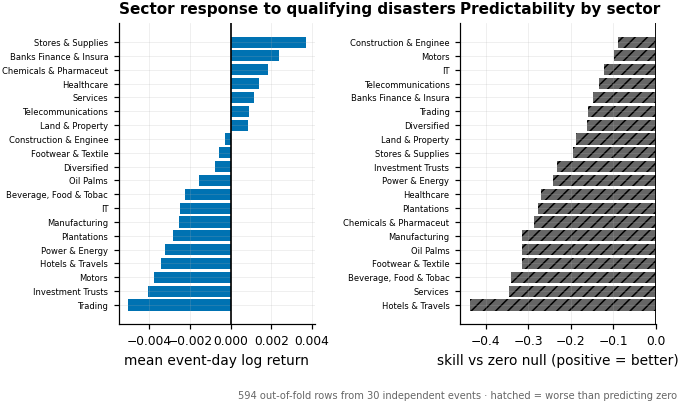

In [10]:
import matplotlib.pyplot as plt

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(6.3, 3.6))
order = by_sector.sort_values("mean")
ax.barh([s[:22] for s in order.index], order["mean"], color=fx.PALETTE["blue"])
ax.axvline(0, color=fx.PALETTE["ink"], linewidth=1.1)
ax.set_xlabel("mean event-day log return")
ax.set_title("Sector response to qualifying disasters")
ax.tick_params(axis="y", labelsize=5.5)

ps = per_sector.sort_values("skill")
bars = ax2.barh([s[:22] for s in ps.index], ps["skill"], color=fx.PALETTE["green"])
for bar, v in zip(bars, ps["skill"]):
    if v <= 0:
        bar.set_hatch("///")
        bar.set_facecolor(fx.PALETTE["grey"])
ax2.axvline(0, color=fx.PALETTE["ink"], linewidth=1.2)
ax2.set_xlabel("skill vs zero null (positive = better)")
ax2.set_title("Predictability by sector")
ax2.tick_params(axis="y", labelsize=5.5)
fx.stamp(fig, f"{len(yt):,} out-of-fold rows from {len(np.unique(ev))} independent events "
              f"· hatched = worse than predicting zero")
fig.tight_layout()
fx.save_figure(fig, "fig_31_sector_response_and_skill")

save_object(panel_results, "results_sector", "Sector-panel out-of-fold predictions.")
